In [52]:
# Import librerie necessarie
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")

In [53]:
data_path = Path("../data/processed/coverage_gap_analysis.csv")

df = pd.read_csv(data_path)

# 
df.head()

,region,sport,clubs_estimated,platform_clubs,coverage_gap,coverage_rate,priority_score
0,Lombardia,calcio,4080,0,4080,0.0,4080.0
1,Lazio,calcio,3060,0,3060,0.0,3060.0
2,Veneto,calcio,2890,0,2890,0.0,2890.0
3,Emilia-Romagna,calcio,2600,0,2600,0.0,2600.0
4,Campania,calcio,2528,0,2528,0.0,2528.0


In [54]:
print(f"Shape: {df.shape}")

Shape: (200, 7)


In [55]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   region           200 non-null    str    
 1   sport            200 non-null    str    
 2   clubs_estimated  200 non-null    int64  
 3   platform_clubs   200 non-null    int64  
 4   coverage_gap     200 non-null    int64  
 5   coverage_rate    200 non-null    float64
 6   priority_score   200 non-null    float64
dtypes: float64(2), int64(3), str(2)
memory usage: 11.1 KB


In [56]:
df.describe()

,clubs_estimated,platform_clubs,coverage_gap,coverage_rate,priority_score
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,464.000000,2.625000,461.375000,0.008505,458.849800
std,575.650421,6.942287,574.987126,0.018991,574.412395
min,24.000000,0.000000,22.000000,0.000000,20.170000
25%,144.000000,0.000000,144.000000,0.000000,144.000000
50%,274.500000,0.000000,273.500000,0.000000,268.235000
75%,564.000000,0.000000,563.250000,0.000000,554.000000
max,4080.000000,45.000000,4080.000000,0.117000,4080.000000


In [57]:
df.isna().sum()

region             0
sport              0
clubs_estimated    0
platform_clubs     0
coverage_gap       0
coverage_rate      0
priority_score     0
dtype: int64

In [58]:
df.sort_values("priority_score", ascending=False).head(10)

,region,sport,clubs_estimated,platform_clubs,coverage_gap,coverage_rate,priority_score
0,Lombardia,calcio,4080,0,4080,0.00,4080.00
1,Lazio,calcio,3060,0,3060,0.00,3060.00
2,Veneto,calcio,2890,0,2890,0.00,2890.00
3,Emilia-Romagna,calcio,2600,0,2600,0.00,2600.00
4,Campania,calcio,2528,0,2528,0.00,2528.00
5,Toscana,calcio,2380,0,2380,0.00,2380.00
6,Piemonte,calcio,2376,0,2376,0.00,2376.00
7,Sicilia,calcio,2280,0,2280,0.00,2280.00
8,Puglia,calcio,2184,0,2184,0.00,2184.00
9,Lombardia,tennis,1500,45,1455,0.03,1411.35


In [59]:
coverage_by_region = (
    df.groupby("region")["coverage_rate"]
    .mean()
    .sort_values()
)

coverage_by_region

region
Toscana                  0.0047
Marche                   0.0055
Lazio                    0.0056
Basilicata               0.0056
Piemonte                 0.0068
Trentino-Alto Adige      0.0075
Sicilia                  0.0078
Lombardia                0.0078
Calabria                 0.0080
Puglia                   0.0081
Veneto                   0.0082
Friuli-Venezia Giulia    0.0082
Campania                 0.0085
Emilia-Romagna           0.0086
Umbria                   0.0088
Abruzzo                  0.0095
Liguria                  0.0104
Molise                   0.0109
Valle d'Aosta            0.0141
Sardegna                 0.0155
Name: coverage_rate, dtype: float64

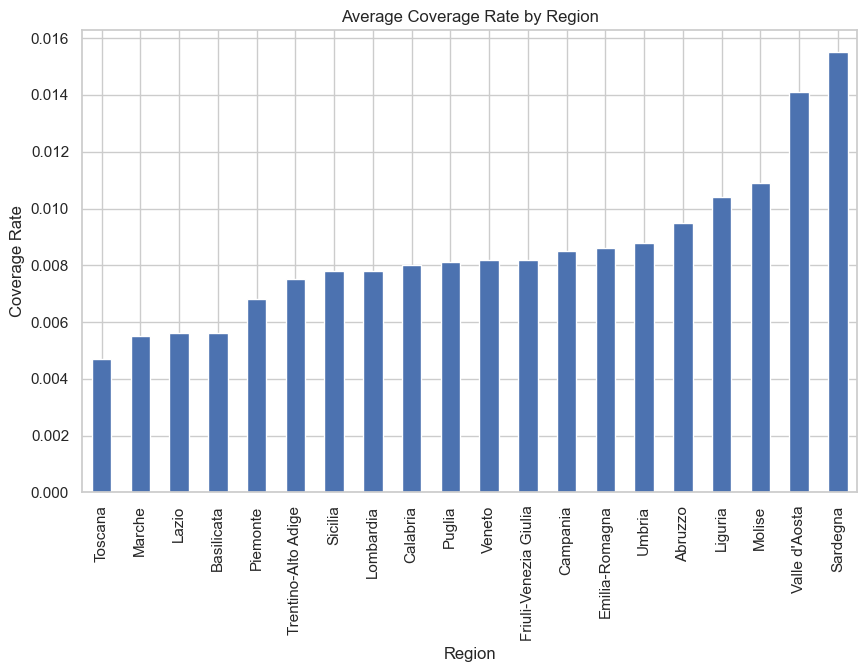

In [60]:
plt.figure(figsize=(10,6))

coverage_by_region.plot(kind="bar")

plt.title("Average Coverage Rate by Region")
plt.ylabel("Coverage Rate")
plt.xlabel("Region")

plt.show()

In [61]:
coverage_by_sport = (
    df.groupby("sport")["coverage_rate"]
    .mean()
    .sort_values()
)

plt.tight_layout()
plt.savefig("../reports/coverage_gap_by_sport.png")

coverage_by_sport

sport
arti_marziali    0.00000
atletica         0.00000
basket           0.00000
calcio           0.00000
ciclismo         0.00000
ginnastica       0.00000
nuoto            0.00000
volley           0.00000
tennis           0.03850
padel            0.04655
Name: coverage_rate, dtype: float64

<Figure size 640x480 with 0 Axes>

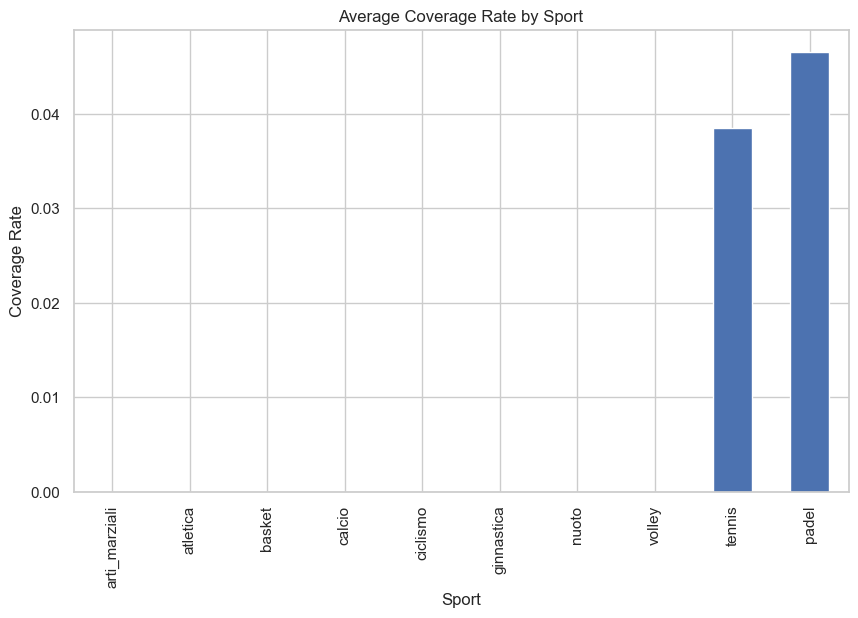

In [62]:
plt.figure(figsize=(10,6))

coverage_by_sport.plot(kind="bar")

plt.title("Average Coverage Rate by Sport")
plt.ylabel("Coverage Rate")
plt.xlabel("Sport")

plt.show()

In [63]:
gap_by_region = (
    df.groupby("region")["coverage_gap"]
    .sum()
    .sort_values(ascending=False)
)

gap_by_region

region
Lombardia                11932
Lazio                     8951
Veneto                    8449
Emilia-Romagna            7958
Piemonte                  7162
Toscana                   6770
Campania                  6364
Sicilia                   5965
Puglia                    5572
Liguria                   3077
Marche                    2986
Abruzzo                   2783
Friuli-Venezia Giulia     2584
Trentino-Alto Adige       2483
Sardegna                  2384
Calabria                  2288
Umbria                    1886
Basilicata                1195
Molise                     892
Valle d'Aosta              594
Name: coverage_gap, dtype: int64

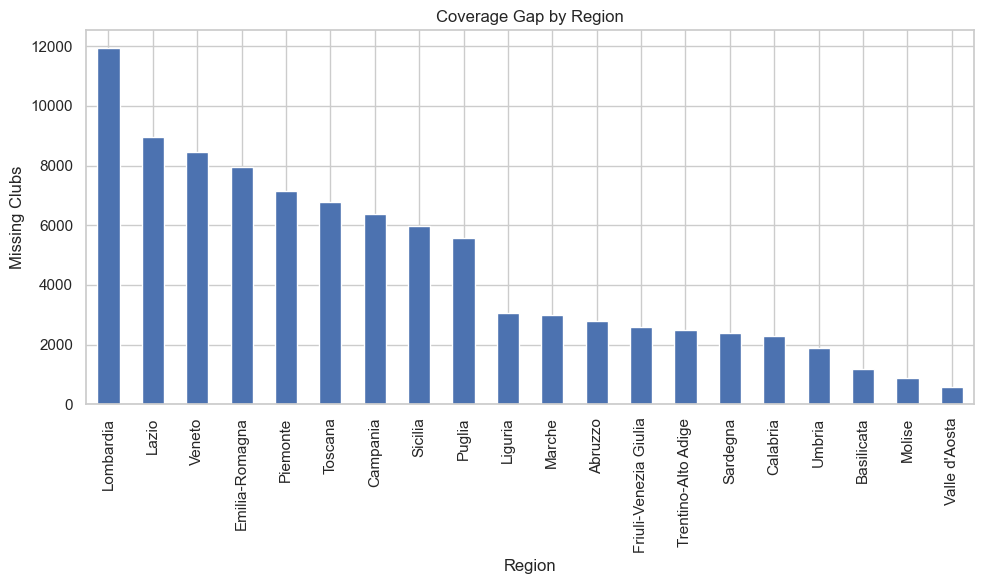

In [64]:
plt.figure(figsize=(10,6))

gap_by_region.plot(kind="bar")

plt.title("Coverage Gap by Region")
plt.ylabel("Missing Clubs")
plt.xlabel("Region")

plt.tight_layout()
plt.savefig("../reports/coverage_gap_by_region.png")

plt.show()

In [65]:
top_opportunities = df.sort_values(
    "priority_score",
    ascending=False
).head(15)

top_opportunities

,region,sport,clubs_estimated,platform_clubs,coverage_gap,coverage_rate,priority_score
0,Lombardia,calcio,4080,0,4080,0.00,4080.00
1,Lazio,calcio,3060,0,3060,0.00,3060.00
2,Veneto,calcio,2890,0,2890,0.00,2890.00
3,Emilia-Romagna,calcio,2600,0,2600,0.00,2600.00
4,Campania,calcio,2528,0,2528,0.00,2528.00
5,Toscana,calcio,2380,0,2380,0.00,2380.00
6,Piemonte,calcio,2376,0,2376,0.00,2376.00
7,Sicilia,calcio,2280,0,2280,0.00,2280.00
8,Puglia,calcio,2184,0,2184,0.00,2184.00
9,Lombardia,tennis,1500,45,1455,0.03,1411.35


In [66]:
pivot_gap = df.pivot_table(
    index="region",
    columns="sport",
    values="coverage_gap"
)

pivot_gap

sport,arti_marziali,atletica,basket,calcio,ciclismo,ginnastica,nuoto,padel,tennis,volley
region,,,,,,,,,,
Abruzzo,182.0,168.0,252.0,1092.0,112.0,140.0,196.0,106.0,255.0,280.0
Basilicata,78.0,72.0,108.0,468.0,48.0,60.0,84.0,47.0,110.0,120.0
Calabria,149.0,138.0,207.0,897.0,92.0,115.0,161.0,88.0,211.0,230.0
Campania,480.0,384.0,576.0,2528.0,224.0,320.0,448.0,247.0,517.0,640.0
Emilia-Romagna,400.0,480.0,840.0,2600.0,520.0,400.0,720.0,226.0,972.0,800.0
Friuli-Venezia Giulia,130.0,156.0,234.0,884.0,169.0,130.0,234.0,99.0,314.0,234.0
Lazio,450.0,540.0,720.0,3060.0,450.0,450.0,765.0,656.0,1050.0,810.0
Liguria,155.0,186.0,248.0,1023.0,217.0,155.0,325.0,116.0,373.0,279.0
Lombardia,600.0,720.0,1080.0,4080.0,780.0,600.0,1080.0,457.0,1455.0,1080.0


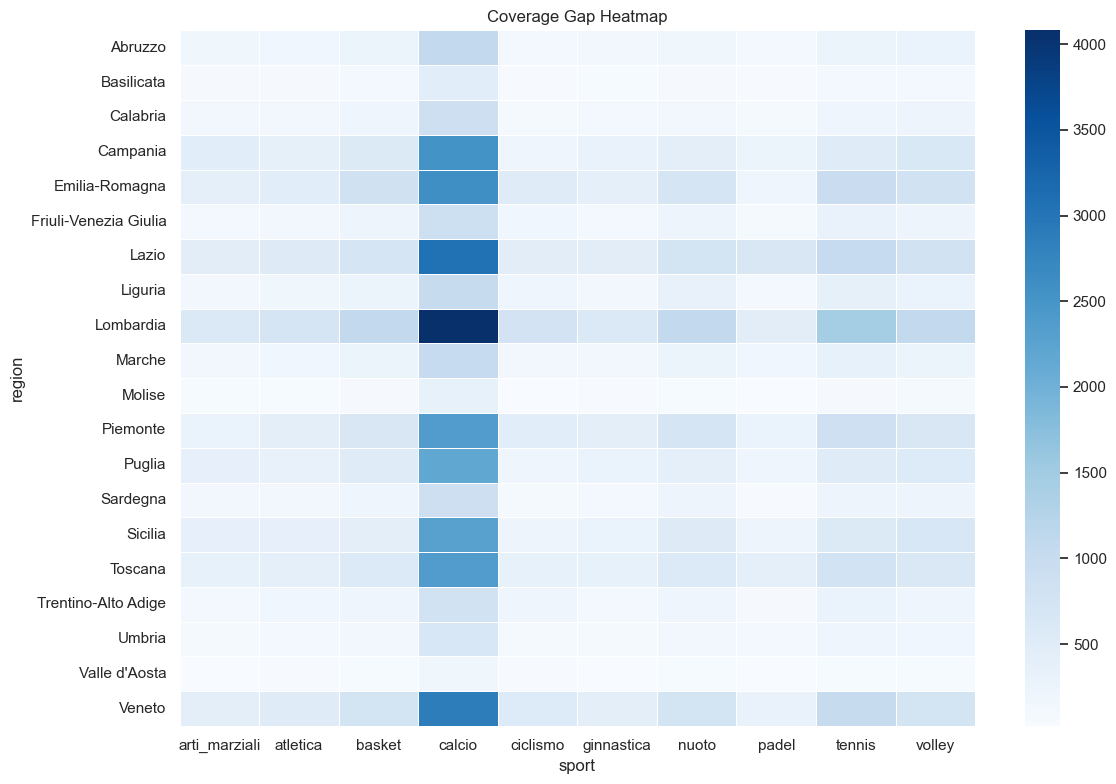

In [67]:
plt.figure(figsize=(12,8))

sns.heatmap(
    pivot_gap,
    cmap="Blues",
    linewidths=0.5
)

plt.title("Coverage Gap Heatmap")


plt.tight_layout()
plt.savefig("../reports/coverage_gap_heatmap.png")

plt.show()

## Example Key Insights

1. Some regions show significantly lower platform coverage compared to the estimated market supply.

2. Certain sports exhibit larger coverage gaps, indicating potential areas for platform expansion.

3. The priority score highlights region-sport combinations where market opportunity is highest.